# Datos Categoricos con Seaborn

## Introducción

***Gráfica Categóricas***
* `Catplot`:
1. Dispersión:
    * `strip`.
    * `swarm`.
2. Distribución:
    * `box`.
    * `boxen`.
    * `violin`.
3. Estimación:
    * `point`.
    * `bar`.
    * `count`.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(0)

df = pd.DataFrame({
    "edad": np.random.randint(18,60,200),
    "ingreso": np.random.normal(15000,5000,200),
})
df["grupo"] = np.where(df["edad"] < 30, "Joven", "Adulto")
df["sal_prom"] = np.where(df["ingreso"] > df["ingreso"].mean(), "alto", "bajo")

## Bloxplot

* Separo por grupo los datos.
* distribución de ingreso ENTRE grupos.
* Tienen la misma mediana, ambos grupos vienen de la misma distribución.
* No hay diferencias significativas entre los grupos.
* Las pequeñas variaciones son ruido de muestreo.

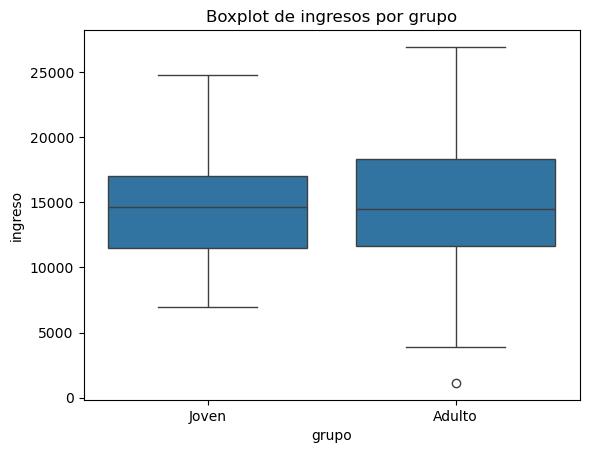

In [2]:
sns.boxplot(data=df, x="grupo", y="ingreso")
plt.title("Boxplot de ingresos por grupo")
plt.show()

## Violinplot

* Este gráfico combina: `boxplot` + `distribución (KDE)`.
* ***¿Qué debes observar?***
  - forma completa de la distribución.
  - ancho = densidad.
  - parecido a `KDE` pero por grupo.
* El ancho representa: densidad de datos.
* Es decir:
  - ***más ancho*** → más valores en esa zona.
  - ***más delgado*** → menos valores.
* ancho del violín = KDE por grupo.
* Es literalmente lo que viste antes con `kde=True`, pero separado por categoría.
* `boxplot` → precisión ; `violinplot` → intuición visual.

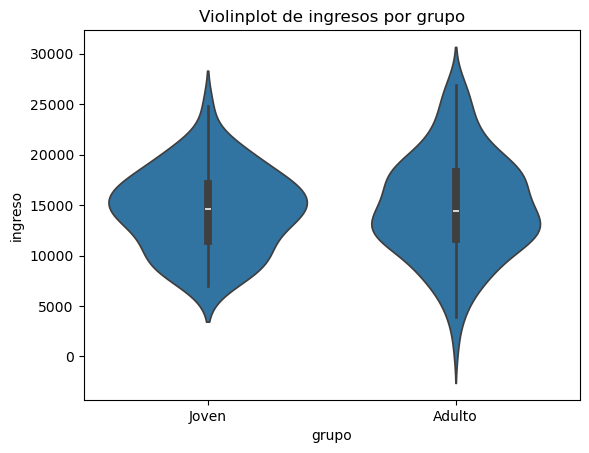

In [3]:
sns.violinplot(data=df, x="grupo", y="ingreso")
plt.title("Violinplot de ingresos por grupo")
plt.show()

* En `sns.violinplot`, el parámetro `inner` controla qué se dibuja dentro del violín (la forma que representa la distribución de los datos).
* `inner="box"` hace que dentro de cada violín se dibuje un mini boxplot. Es decir, agrega información estadística clave encima de la distribución:
  - Mediana (línea central).
  - Rango intercuartílico (IQR) (la “cajita”).
  - Bigotes (extensión típica de los datos).
* ***¿Por qué es útil?***
* El violín ya muestra la forma de la distribución (densidad), pero el `box` te ayuda a ver rápidamente:
  - Dónde está el centro de los datos.
  - Qué tan dispersos están.
  - Comparaciones más claras entre grupos.
* Otros valores de `inner`:
  - `"box"` → mini boxplot (el que estás usando).
  - `"quart"` → solo líneas de cuartiles.
  - `"point"` → puntos individuales (mediana o datos).
  - `"stick"` → líneas para cada observación.
  - `None` → nada dentro del violín
* En resumen: `inner="box"` combina lo mejor de un `violin plot` y un `boxplot` en una sola gráfica.

<Axes: xlabel='grupo', ylabel='ingreso'>

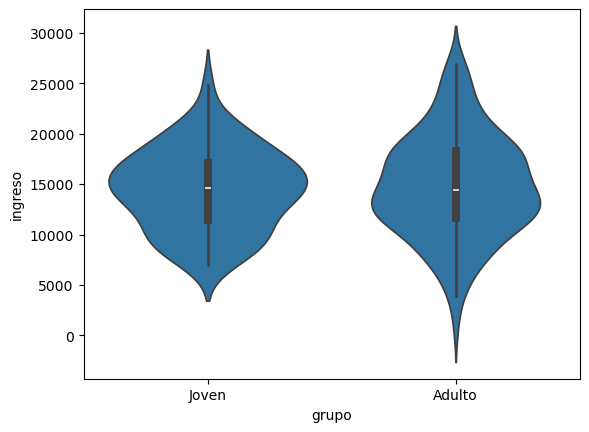

In [4]:
sns.violinplot(data=df, x="grupo", y="ingreso", inner="box")

## Pairplot

* `Pairplot`: es como un mix de varias graficas.
* Sirve para explorar rápidamente las ***relaciones*** entre múltiples variables numéricas en un dataset.
* ***¿Qué es un pairplot?***
* Un `pairplot` (o “gráfico de pares”) muestra:
  - Gráficas de dispersión (`scatter plots`) entre cada par de variables.
  - Distribuciones individuales (`histogramas o KDE`) en la diagonal.
* Básicamente, crea una matriz donde puedes ver todas las ***combinaciones posibles de variables al mismo tiempo***.
* ***¿Cómo funciona?***
  - ***Diagonal*** → distribución de cada variable.
  - ***Fuera de la diagonal*** → relación entre dos variables.

|            | edad vs edad | edad vs ingreso | edad vs gasto |
| ---------- | ------------ | -------------- | ------------ |
| **edad**   | histograma   | scatter        | scatter      |
| **ingreso** | scatter      | histograma     | scatter      |
| **gasto**   | scatter      | scatter        | histograma   |

* Un `pairplot` es útil para:
  - Detectar correlaciones entre variables.
  - Identificar patrones o tendencias.
  - Ver clusters o grupos (por ejemplo, usando hue).
  - Encontrar outliers (valores atípicos).

In [5]:
df2 = pd.DataFrame({
    "edad": np.random.randint(18,60,200),
    "ingreso": np.random.normal(15000,5000,200),
    "gasto": np.random.normal(8000,3000,200)
})

df2["grupo"] = np.where(df2["edad"] < 30, "Joven", "Adulto")

* ***¿Por qué parece correlación?***
* Porque visualmente:
  - Los puntos siguen cierta tendencia.
  - No están completamente aleatorios.
* La correlación que ves puede ser ilusión visual.
* No hay separación clara entre clases.
* ***¿Qué hace `corner=True`?***
  - Elimina duplicados, hablando de graficos.
  - Menos ruido visual, por lo tanto más fácil de interpretar.

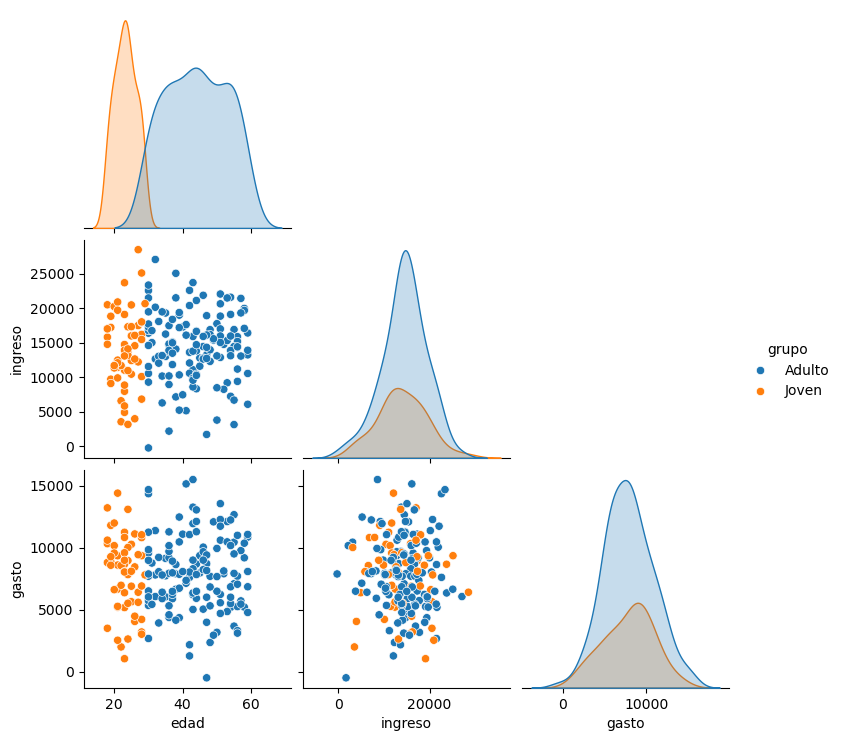

In [7]:
#sns.pairplot(df2, hue="grupo")
sns.pairplot(df2, hue="grupo", corner=True)

## Heatmap

* ***¿Cómo se calcula la correlación?***
* La correlación mide qué tan relacionadas están dos variables numéricas.
* La más común es la correlación de ***Pearson***, que es la que usa `df.corr()` por defecto.
* La formula esta dada por:
$$r = \frac{\text{cov(X,Y)}}{\sigma_X \cdot \sigma_Y}$$
* Donde $\text{cov(X,Y)}$ es la covarianza de X y Y.
* Además $\sigma_x$ y $\sigma_y$ son las desviaciones estándar.
* `numeric_only=True` → ignora columnas de texto (strings, categorías, etc.).
* `annot=True` → muestra los números dentro de cada celda.
* `cmap="coolwarm"`:
  - ***azul*** = correlación negativa.
  - ***rojo*** = correlación positiva.
  - ***blanco*** = cerca de 0.
* ***CONSIDERACIONES***:
  - La correlación NO implica causalidad.
  - Solo detecta relaciones lineales.
  - Valores extremos (`outliers`) pueden afectar mucho.
* todos cerca de 0 → no hay correlación --> variables independientes.
* ***Flujo correcto en Data Science***:
  - `pairplot` → detectar posibles relaciones.
  - `heatmap` → validar correlaciones.
  - `conclusiones` → con evidencia.

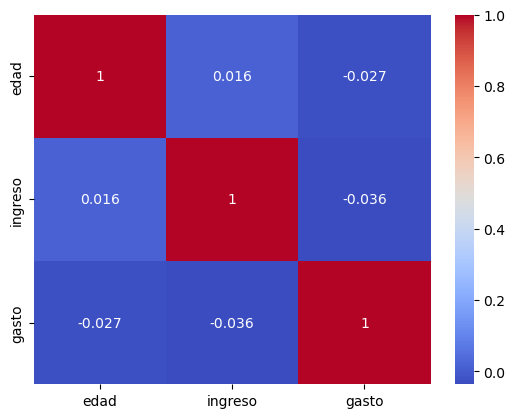

In [8]:
corr = df2.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

# Ejercicio

### Datos Categóricos a Visualizar

* Establecemos el tipo ticks, con talk como de conferencia y los colores de tab10
* Pre cargamos la información de seaborn

In [9]:
sns.set_theme(style="ticks", context="talk", palette="tab10")

# Cargamos los datos de la base de datos propinas
consumos = sns.load_dataset("tips")

# Definimos las columnas y que las de default vienen en inglés.
consumos.columns = ["total", "propina", "genero", "fumador", "dia", "tipo", "comensales"]
consumos

,total,propina,genero,fumador,dia,tipo,comensales
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


## Gráficas Categóricas de Dispersión

### Gráfica stripplot (gráficas de Bandas)

* Por default, esta gráfica nos pone separados los puntitos para poder diferenciar, pero su apagamos el jitter, se alinearán todos, quizas en algunos casos se vea bien ,pero en este no se tan bien.
* Kind:
* Hue: es el matiz, es lo que pone el mensaje de comensales y los separa.
* col: es una variable categorica, lo que nos generá 2 g´raficas en este caso

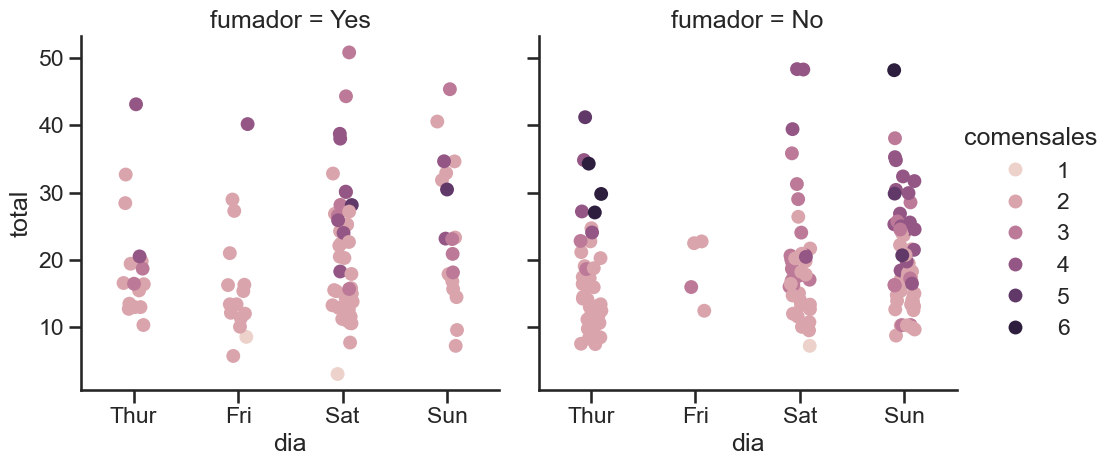

In [10]:
sns.catplot(data=consumos, 
            x="dia", 
            y="total", 
            jitter=True,
            kind="strip",
           hue="comensales",
           col="fumador",
           s=100)
plt.show()

### Gráfica swarmplot (Colmena de Abejas)

* Esta no tiene jitter
* Cambiamos el kind a swarm.
* A diferencia del de bandas, este no los amontona juntos, los separa y los pone al mismo nivel todo los datos, ya que en anterior se ve un puñado de puntos muy junto.
* Se utiliza cuando son pocos datos, ya que sin muchos es muy poco informativa

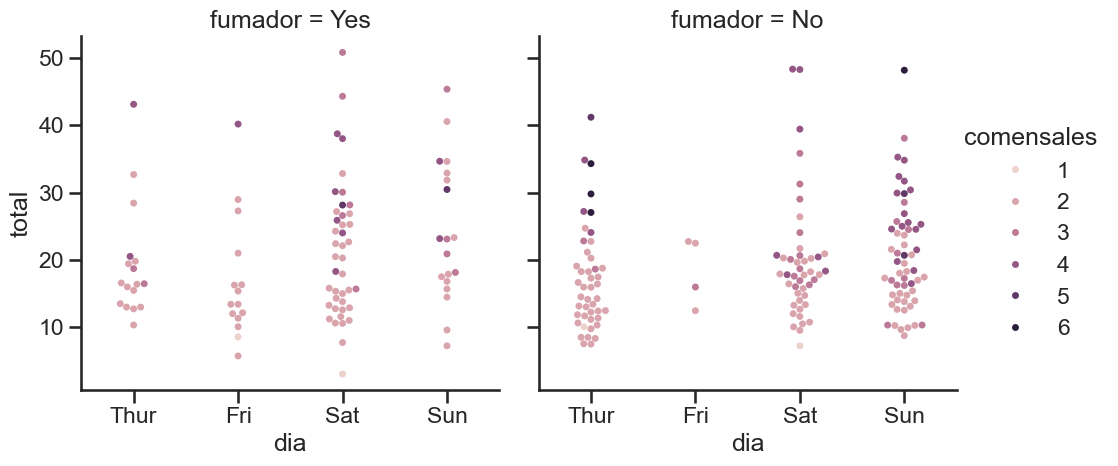

In [11]:
sns.catplot(data=consumos, 
            x="dia", 
            y="total", 
            kind="swarm",
           hue="comensales",
           col="fumador")
plt.show()

## Gráficas Categóricas de Distribución

### Gráficas Bloxplot (Gráfica de Cajas)

* Este es el que trae los cuartiles y los valores fuera de la media.
* Es muy popular porque es muy útil.
* Los bigotes representan el valor minimo y máximo. La linea de en medio es la mediana,ya que estamos asumiendo que los valores están ordenados.
* Las cajas funcionan así, del Bigote menor a la primera linea es el 25% de nuestros datos (Cuartil 1), de esa linea a la mediana es el 50% de nuestros datos, la mediana a linea final de la caja será el 75% y así hasta llegar al 100% de nuestros datos.
* Los puntitos son los datos outliers o fuera de rango.

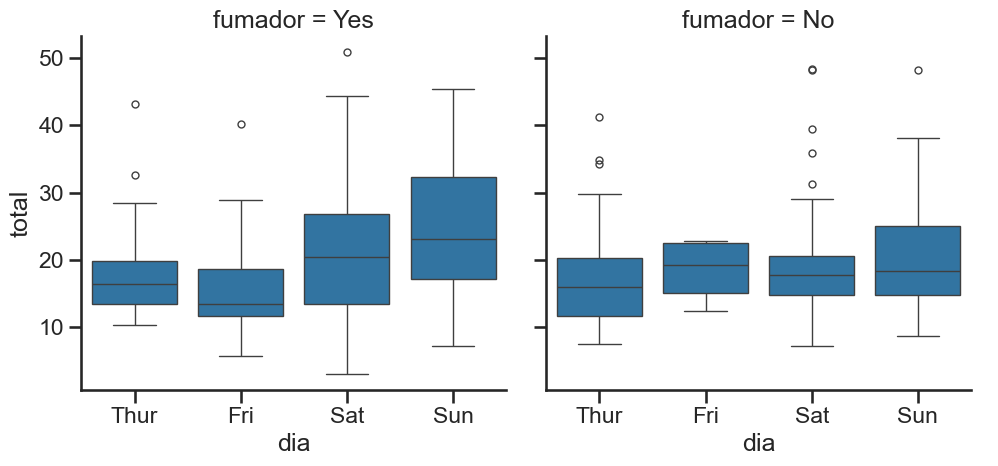

In [12]:
sns.catplot(data=consumos, 
            x="dia", 
            y="total", 
            kind="box",
           col="fumador")
plt.show()

### Gráfica Boxenplot

* Nos presentan información parecida al anterior.
* Solo se recomiendan trabajar con esta cuando son muchos datos.
* No tan digeribles para las personas que no ven estos temas.

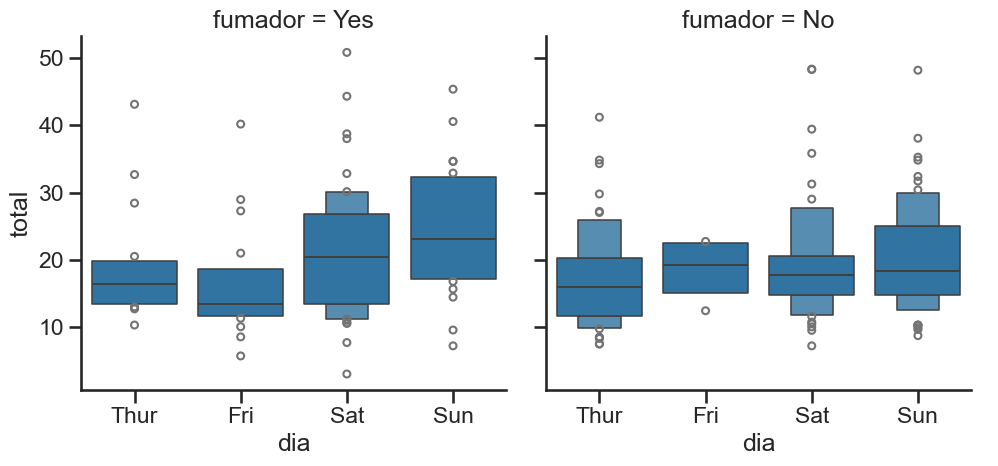

In [13]:
sns.catplot(data=consumos, 
            x="dia", 
            y="total", 
            kind="boxen",
           col="fumador")
plt.show()

### Gráfica Violinplot

* Es lo mismo que la de cajas, nos trae los cuartiles, pero nos trae una distribución aproximada de los datos.
* La curva o pancita de esta muy cerca de la mediana, por lo que podría serguir una distribución normal.
* En la siguiente gráfica, los separó por fumador, para ver que distribución sigue cada dato.
* Pero se ve algo feo, por lo que podemos usar split, lo cual la parte a la mitas y lo compara con la otra mitad de los no fumadores.

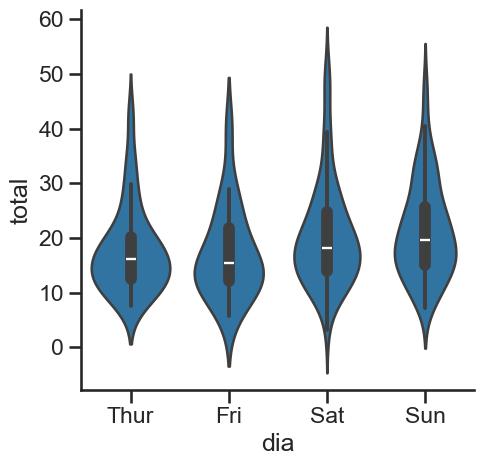

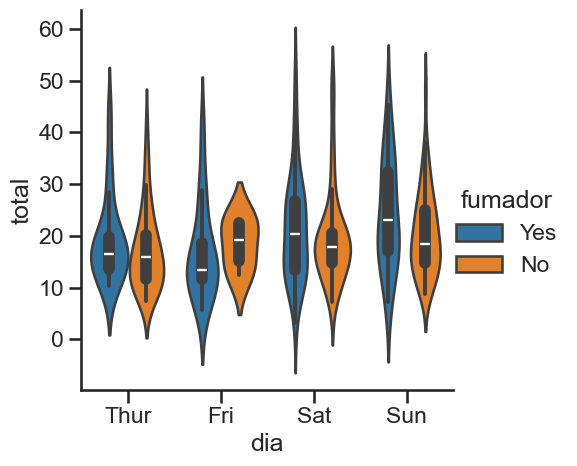

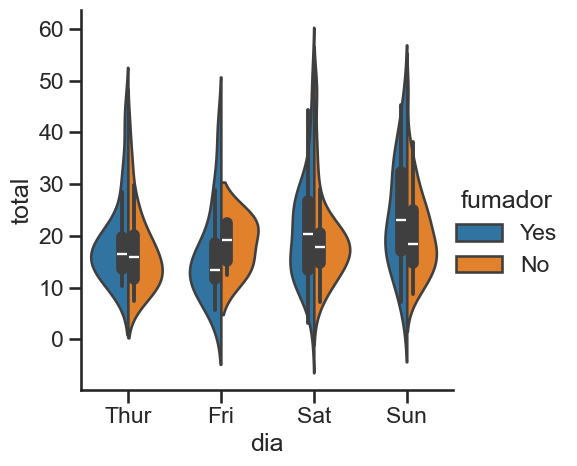

In [14]:
sns.catplot(data=consumos, 
            x="dia", 
            y="total", 
            kind="violin")

sns.catplot(data=consumos, 
            x="dia", 
            y="total", 
            kind="violin",
            hue="fumador")

sns.catplot(data=consumos, 
            x="dia", 
            y="total", 
            kind="violin",
            hue="fumador",
           split=True)
plt.show()

## Gráficas Categóricas de Estimación

### Gráfica de Pointplot

* Los puntos hacen referencia a los consumos promedios.
* Cada linea es el Intervalo de Confianza al 95%.

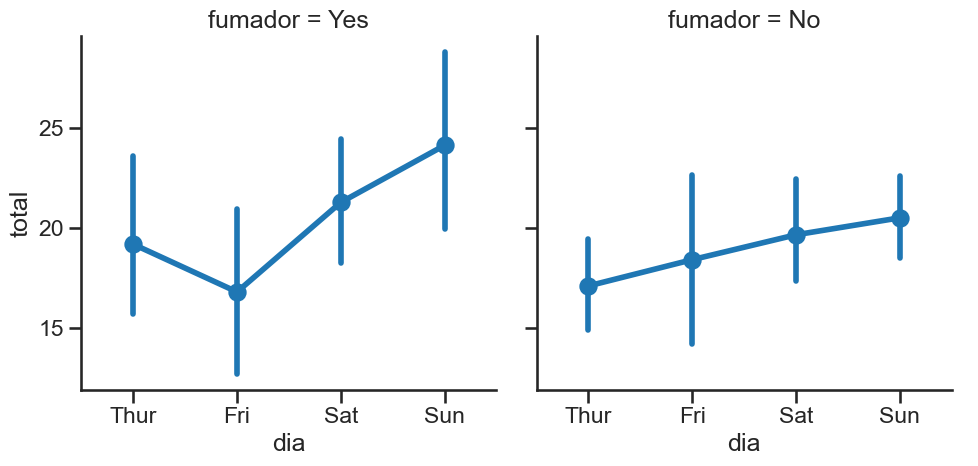

In [15]:
sns.catplot(data=consumos, 
            x="dia", 
            y="total", 
            kind="point",
           col="fumador")
plt.show()

### Gráfica Barplot

* EN lugar de usar el punto, usa barras donde el tope es el promedio.

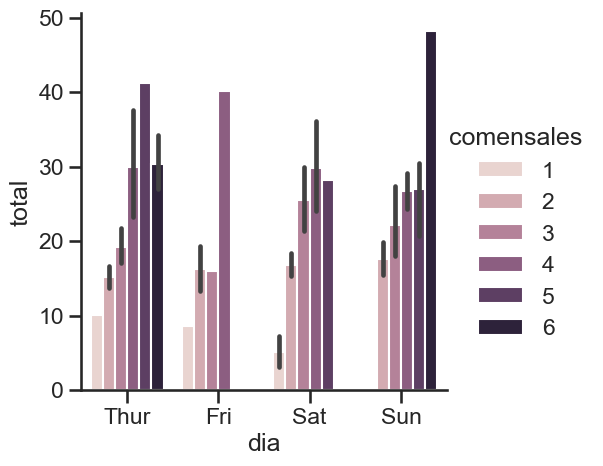

In [16]:
sns.catplot(data=consumos, 
            x="dia", 
            y="total", 
            kind="bar",
           hue="comensales")
plt.show()

### Gráfica Countplot

* La misma información que obtendrímos en un histograma.
* La mayoría de los comensales fueron de 2 comensales.
* No hay eje y.

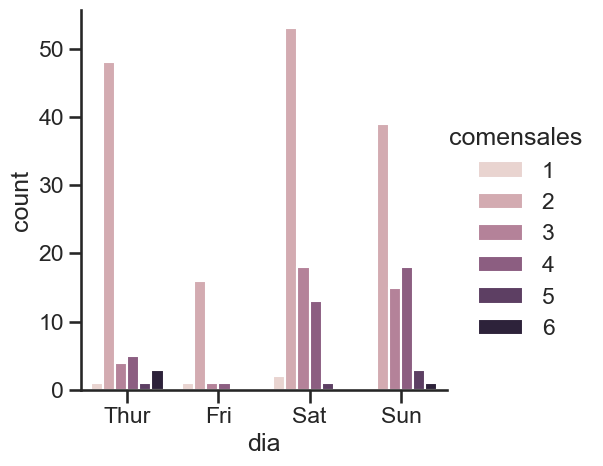

In [17]:
sns.catplot(data=consumos, 
            x="dia", 
            kind="count",
           hue="comensales")
plt.show()